In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.preprocessing import MinMaxScaler

In [2]:
# Load MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target.astype(int)

print(f"Dataset shape: {X.shape}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Classes: {np.unique(y)}")
print(f"Missing values: {np.isnan(X).sum()}")
print(f"Pixel value range: {X.min()} to {X.max()}")

Dataset shape: (70000, 784)
Number of classes: 10
Classes: [0 1 2 3 4 5 6 7 8 9]
Missing values: 0
Pixel value range: 0 to 255


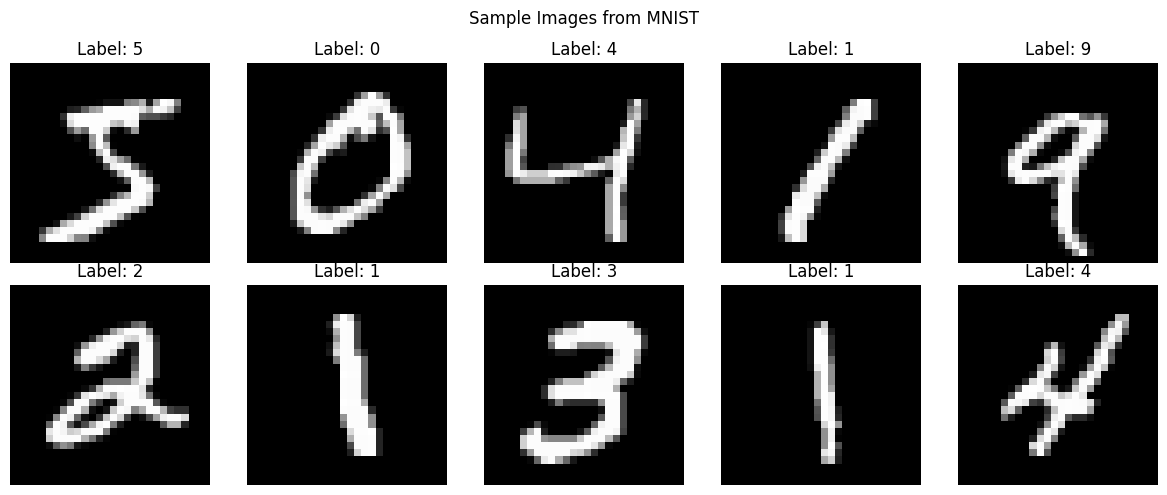

In [3]:
# Visualize sample digits
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X[i].reshape(28, 28), cmap='gray')
    ax.set_title(f"Label: {y[i]}")
    ax.axis('off')
plt.suptitle("Sample Images from MNIST")
plt.tight_layout()
plt.show()

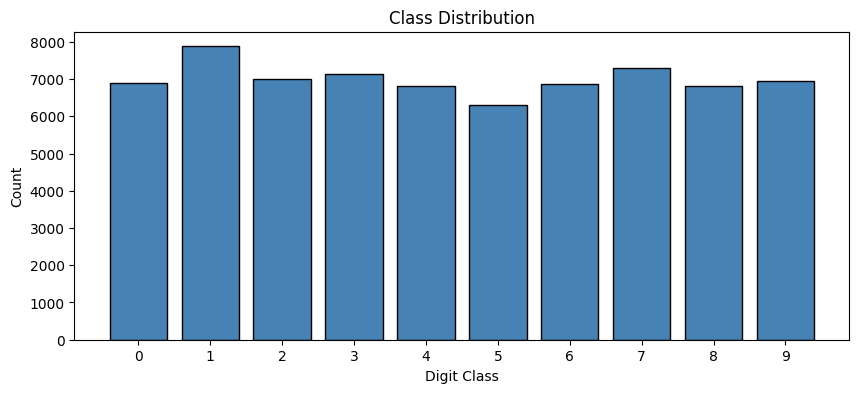

0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958


In [4]:
# Check class balance
unique, counts = np.unique(y, return_counts=True)
plt.figure(figsize=(10, 4))
plt.bar(unique, counts, color='steelblue', edgecolor='black')
plt.xlabel("Digit Class")
plt.ylabel("Count")
plt.title("Class Distribution")
plt.xticks(unique)
plt.show()

print(pd.Series(counts, index=unique).to_string())

Digit 1 has more samples (~7900). Digit 5 has slightly fewer (~6300)

## Data Format Note
MNIST consists of 28×28 grayscale images, which are non-tabular by nature. However, this project treats each image as a flat row of 784 pixel values, making it a standard tabular classification problem. Feature selection (Variance Threshold + Mutual Information) then reduces this to 30 columns — the most discriminative pixels, resulting in a compact tabular dataset well within project requirements.


In [5]:
# Normalize pixel values to 0-1 range
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f"Before scaling - min: {X.min()}, max: {X.max()}")
print(f"After scaling  - min: {X_scaled.min():.2f}, max: {X_scaled.max():.2f}")

Before scaling - min: 0, max: 255
After scaling  - min: 0.00, max: 1.00


In [6]:
# --- FEATURE SELECTION TECHNIQUE 1: Variance Threshold ---
# Remove pixels that are nearly always the same value (low variance = not useful)

selector_var = VarianceThreshold(threshold=0.01)
X_var = selector_var.fit_transform(X_scaled)

print(f"Features before Variance Threshold: {X_scaled.shape[1]}")
print(f"Features after  Variance Threshold: {X_var.shape[1]}")
print(f"Features removed: {X_scaled.shape[1] - X_var.shape[1]}")

Features before Variance Threshold: 784
Features after  Variance Threshold: 443
Features removed: 341


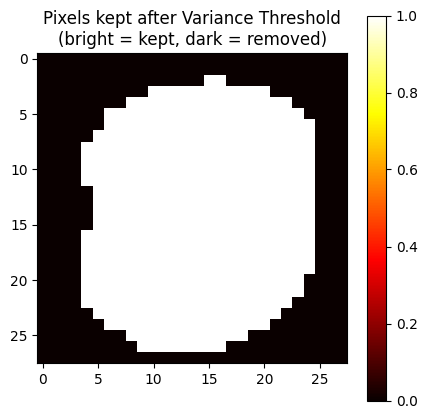

In [7]:
# Visualize which pixels survived variance threshold
mask = selector_var.get_support()
pixel_map = mask.reshape(28, 28)

plt.figure(figsize=(5, 5))
plt.imshow(pixel_map, cmap='hot')
plt.title("Pixels kept after Variance Threshold\n(bright = kept, dark = removed)")
plt.colorbar()
plt.show()

In [ ]:
# --- FEATURE SELECTION TECHNIQUE 2: Mutual Information ---
# Measure how much each pixel's value tells us about the digit label
# Higher score = more useful for prediction

print("Calculating mutual information scores... (this takes ~1 min)")
mi_scores = mutual_info_classif(X_var, y, random_state=42)

print("Done!")
print(f"Highest MI score: {mi_scores.max():.4f}")
print(f"Lowest MI score:  {mi_scores.min():.4f}")

Calculating mutual information scores... (this takes ~1 min)
Done!
Highest MI score: 0.2853
Lowest MI score:  0.0141


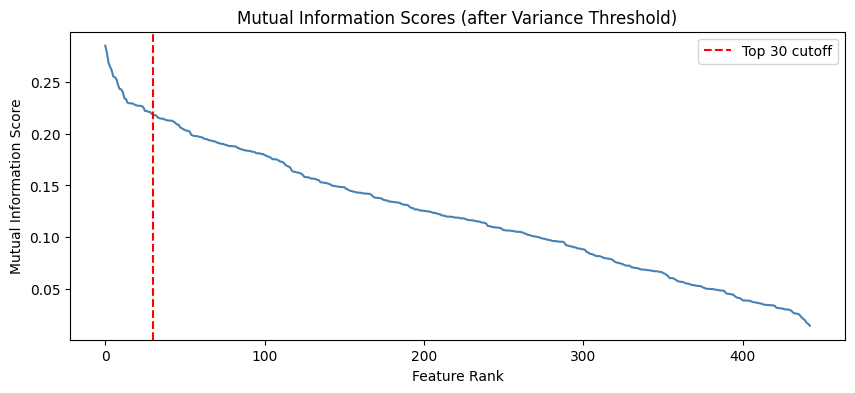

Features after Mutual Information selection: 30


In [9]:
# Plot MI scores
plt.figure(figsize=(10, 4))
plt.plot(sorted(mi_scores, reverse=True), color='steelblue')
plt.axvline(x=30, color='red', linestyle='--', label='Top 30 cutoff')
plt.xlabel("Feature Rank")
plt.ylabel("Mutual Information Score")
plt.title("Mutual Information Scores (after Variance Threshold)")
plt.legend()
plt.show()

# Select top 30 features
top_k = 30
top_indices = np.argsort(mi_scores)[::-1][:top_k]
X_selected = X_var[:, top_indices]

print(f"Features after Mutual Information selection: {X_selected.shape[1]}")

the curve drops steeply in the first ~30 features, then flattens out into a long tail. That's called an "elbow" — it means the first 30 features carry most of the useful information, and everything after that adds diminishing returns. That's why cutting at 30 is fine. 

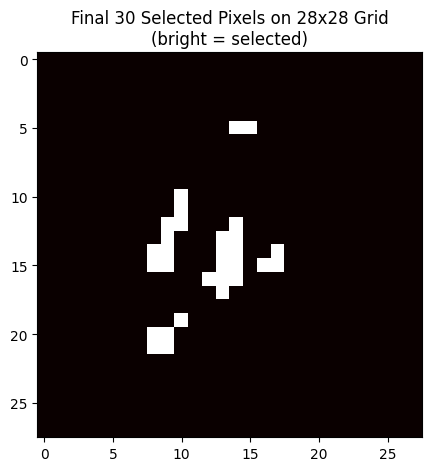

In [10]:
# Map selected pixels back to the original 28x28 grid
var_mask = selector_var.get_support()
var_indices = np.where(var_mask)[0]  # original pixel indices that survived variance threshold
selected_original_indices = var_indices[top_indices]  # map back to original 784 pixels

final_pixel_map = np.zeros(784)
final_pixel_map[selected_original_indices] = 1
final_pixel_map = final_pixel_map.reshape(28, 28)

plt.figure(figsize=(5, 5))
plt.imshow(final_pixel_map, cmap='hot')
plt.title("Final 30 Selected Pixels on 28x28 Grid\n(bright = selected)")
plt.show()

In [11]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Final feature count: {X_selected.shape[1]}")
print(f"Training samples:    {X_train.shape[0]}")
print(f"Test samples:        {X_test.shape[0]}")

# Save processed data
np.save('X_train.npy', X_train)
np.save('X_test.npy', X_test)
np.save('y_train.npy', y_train)
np.save('y_test.npy', y_test)

print("Processed datasets saved!")

Final feature count: 30
Training samples:    56000
Test samples:        14000
Processed datasets saved!
